# 4 — Model Evaluation (Business Impact)

Questo notebook trasforma le metriche tecniche in **valore di business**.
Oltre alla calibrazione e precisione, analizziamo:
1.  **ROI Simulation**: Quanto guadagneremmo usando il modello?
2.  **Error Analysis**: Chi sono i False Positives (i "soldi sprecati")?
3.  **Lift & Gain**: Quanto è meglio il modello rispetto al caso?

---

In [28]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve
# import scikitplot as skplt # REMOVED due to scipy incompatibility

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# 1. Caricamento Modello e Dati
try:
    model = joblib.load('../models/final_model.joblib')
    print(f"✅ Modello caricato: {type(model).__name__}")
except FileNotFoundError:
    print("⚠️ Modello non trovato. Esegui 'train_model.py'.")
    model = None

test_df = pd.read_csv('../data/processed/KICKSTARTER_TEST.csv')
X_test = test_df.drop('target', axis=1)
y_test = test_df['target']

print(f"✅ Test Set: {X_test.shape}")

✅ Modello caricato: CalibratedClassifierCV
✅ Test Set: (37623, 188)


## 2. Business Optimization (Threshold Search)
Il ROI dipende fortemente dalla soglia (Threshold). 
Una soglia bassa accetta più progetti ma rischia più fallimenti (False Positives).
Una soglia alta è più prudente ma rischia di perdere opportunità (False Negatives).

Qui cerchiamo la soglia che **massimizza il ROI**, ma confrontiamo anche **Max Profit** e **Default (0.5)**.

📊 --- Business Strategy Comparison ---


Strategy,Threshold,Invested,Profit,ROI %,Funded,Successes,Failures
Default (0.5),0.50,"$2,473,400","$-4,160",-0.17%,"24,734","20,577","4,157"
Max Profit,0.85,"$1,356,500","$188,980",13.93%,"13,565","12,879",686
Max ROI,0.98,"$423,800","$79,840",18.84%,"4,238","4,197",41


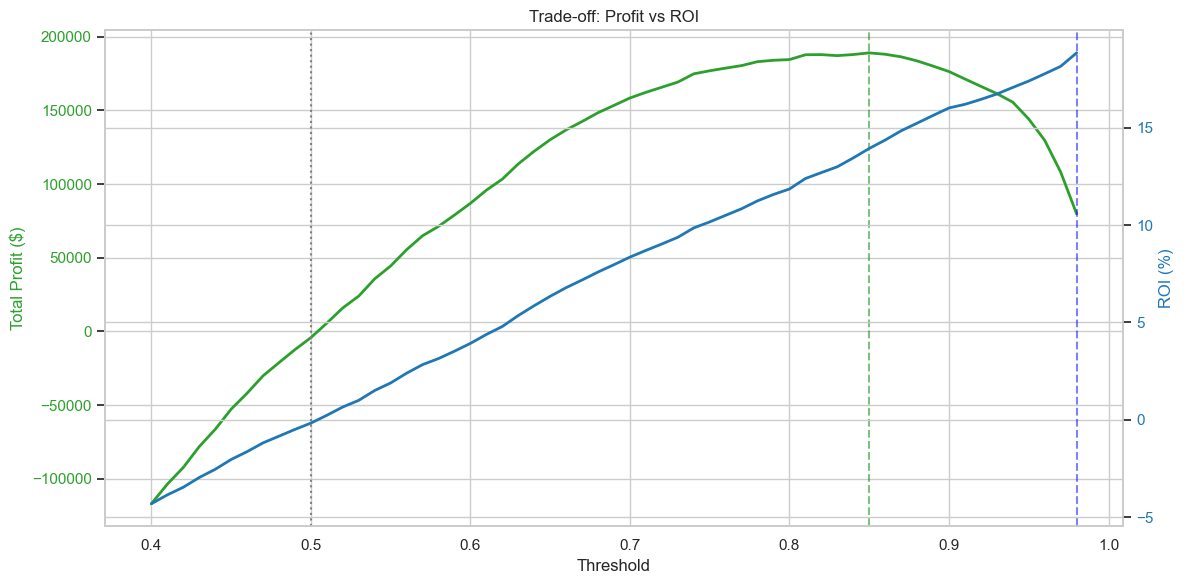


✅ Selected Threshold for Deep Dive: 0.85 (Max Profit Strategy)


In [29]:
if model:
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # --- Simulazione Parametri ---
    INVESTMENT = 100
    RETURN_PCT = 0.20 # 20% guadagno su successo
    
    # 1. Search for Optima across thresholds
    thresholds = np.linspace(0.40, 0.98, 59)
    rois = []
    profits = []
    
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        tp = np.sum((y_pred_t == 1) & (y_test == 1))
        fp = np.sum((y_pred_t == 1) & (y_test == 0))
        
        total_invested = (tp + fp) * INVESTMENT
        if total_invested > 0:
            revenue = tp * INVESTMENT * (1 + RETURN_PCT)
            profit = revenue - total_invested
            roi = (profit / total_invested) * 100
        else:
            profit = 0
            roi = 0
        rois.append(roi)
        profits.append(profit)
    
    # Find Best ROI and Best Profit indices
    best_roi_idx = np.argmax(rois)
    best_roi_thresh = thresholds[best_roi_idx]
    
    best_profit_idx = np.argmax(profits)
    best_profit_thresh = thresholds[best_profit_idx]
    
    # Function to calculate metrics for a specific threshold
    def calculate_metrics(thresh, name):
        y_pred_t = (y_proba >= thresh).astype(int)
        tp = np.sum((y_pred_t == 1) & (y_test == 1))
        fp = np.sum((y_pred_t == 1) & (y_test == 0))
        invested = (tp + fp) * INVESTMENT
        
        if invested > 0:
            unique_profit = (tp * INVESTMENT * (1 + RETURN_PCT)) - invested
            unique_roi = (unique_profit / invested) * 100
        else:
            unique_profit = 0
            unique_roi = 0
            
        return {
            "Strategy": name,
            "Threshold": thresh,
            "Invested": invested,
            "Profit": unique_profit,
            "ROI %": unique_roi,
            "Funded": tp + fp,
            "Successes": tp,
            "Failures": fp
        }
        
    # 2. Compare 3 Scenarios
    # Note: 'Default' usually implies 0.50 if not specified otherwise
    scenarios = [
        calculate_metrics(0.50, "Default (0.5)"),
        calculate_metrics(best_profit_thresh, "Max Profit"),
        calculate_metrics(best_roi_thresh, "Max ROI")
    ]
    
    results_df = pd.DataFrame(scenarios)
    
    # Display Table
    print("📊 --- Business Strategy Comparison ---")
    display(results_df.style.format({
        "Threshold": "{:.2f}",
        "Invested": "${:,.0f}",
        "Profit": "${:,.0f}",
        "ROI %": "{:.2f}%",
        "Funded": "{:,.0f}",
        "Successes": "{:,.0f}",
        "Failures": "{:,.0f}"
    }).hide(axis='index'))
    
    # Plot ROI & Profit vs Threshold
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    color = 'tab:green'
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Total Profit ($)', color=color)
    ax1.plot(thresholds, profits, color=color, linewidth=2, label='Total Profit')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.axvline(best_profit_thresh, color='green', linestyle='--', alpha=0.5, label=f'Max Profit: {best_profit_thresh:.2f}')
    
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('ROI (%)', color=color)
    ax2.plot(thresholds, rois, color=color, linewidth=2, linestyle='-', label='ROI %')
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.axvline(best_roi_thresh, color='blue', linestyle='--', alpha=0.5, label=f'Max ROI: {best_roi_thresh:.2f}')
    
    # Add Default line
    ax2.axvline(0.5, color='gray', linestyle=':', label='Default (0.5)')
    
    plt.title("Trade-off: Profit vs ROI")
    fig.tight_layout()
    plt.show()
    
    # Select 'Max Profit' as the balanced choice for subsequent steps, or stick to Default if preferred.
    # Giving the user valid context: usually Max Profit is the rational business choice over Max ROI % if volume matters.
    # Let's set THRESHOLD to the Max Profit one for the rest of the notebook.
    THRESHOLD = best_profit_thresh
    y_pred = (y_proba >= THRESHOLD).astype(int)
    print(f"\n✅ Selected Threshold for Deep Dive: {THRESHOLD:.2f} (Max Profit Strategy)")

## 3. Business Simulation (Con Soglia Ottimale)
Ricalcoliamo le metriche usando la soglia che abbiamo appena trovato.

In [30]:
if model:
    # Ricalcolo con la soglia ottimale
    invested_projects = y_test[y_pred == 1]
    n_invested = len(invested_projects)
    n_successes = invested_projects.sum() # TP
    n_failures = n_invested - n_successes # FP
    
    total_spent = n_invested * INVESTMENT
    revenue = n_successes * INVESTMENT * (1 + RETURN_PCT)
    profit = revenue - total_spent
    roi = (profit / total_spent) * 100 if total_spent > 0 else 0
    
    print(f"💰 --- Business Simulation (Best Threshold: {THRESHOLD:.2f}) ---")
    print(f"   Progetti Finanziati: {n_invested}")
    print(f"   Successi Reali (TP): {n_successes}")
    print(f"   Fallimenti (FP):     {n_failures} (Soldi Persi)")
    print(f"   -----------------------")
    print(f"   Totale Investito:    ${total_spent:,.0f}")
    print(f"   Profitto Netto:      ${profit:,.0f}")
    print(f"   ROI del Modello:     {roi:.2f}%")

💰 --- Business Simulation (Best Threshold: 0.85) ---
   Progetti Finanziati: 13565
   Successi Reali (TP): 12879
   Fallimenti (FP):     686 (Soldi Persi)
   -----------------------
   Totale Investito:    $1,356,500
   Profitto Netto:      $188,980
   ROI del Modello:     13.93%


## 4. Lift & Gain Charts
Visualizziamo quanto il modello è migliore rispetto a scegliere a caso.

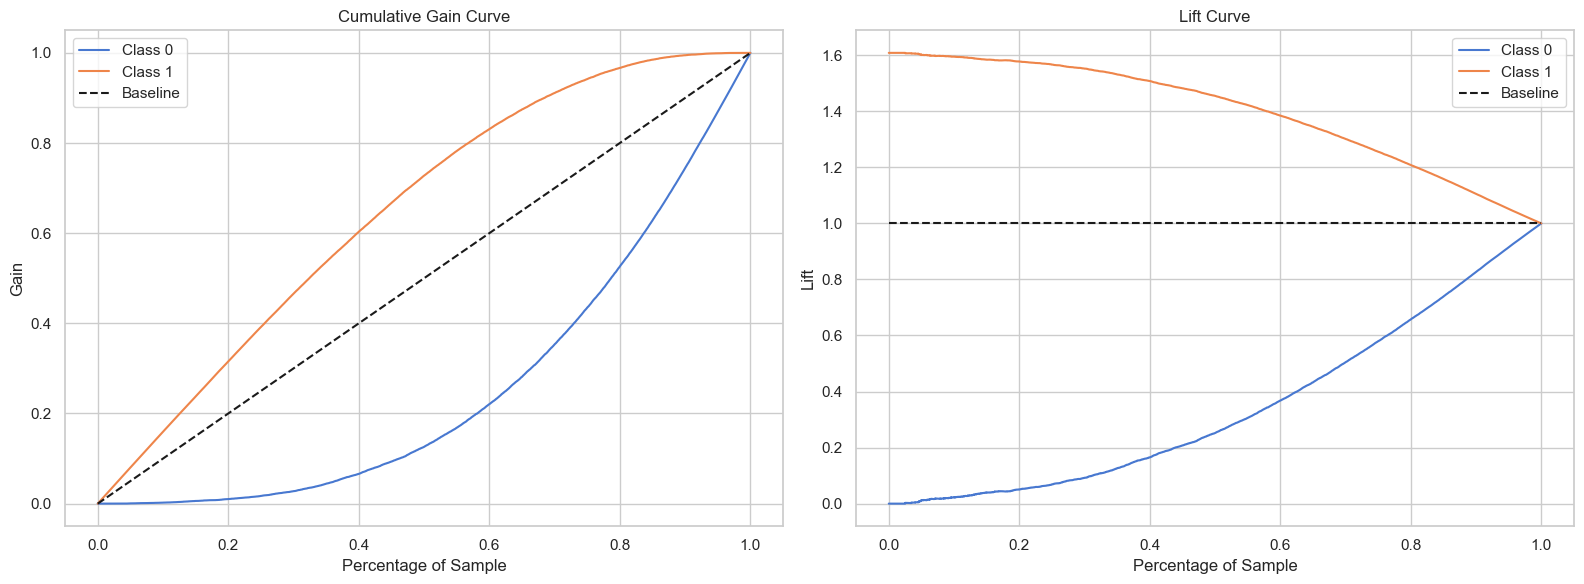

In [31]:
if model:
    classes = np.unique(y_test)
    y_test_array = np.array(y_test)
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- Cumulative Gain ---
    ax[0].set_title("Cumulative Gain Curve")
    for i, c in enumerate(classes):
        indices = np.argsort(y_proba)[::-1]
        sorted_y_true = y_test_array[indices] == c
        gains = np.cumsum(sorted_y_true)
        gains = gains / float(np.sum(sorted_y_true))
        gains = np.insert(gains, 0, 0)
        percentages = np.linspace(0, 1, len(gains))
        ax[0].plot(percentages, gains, label=f"Class {c}")
        
    ax[0].plot([0, 1], [0, 1], "k--", label="Baseline")
    ax[0].set_xlabel("Percentage of Sample")
    ax[0].set_ylabel("Gain")
    ax[0].legend()
    ax[0].grid(True)

    # --- Lift Curve ---
    ax[1].set_title("Lift Curve")
    for i, c in enumerate(classes):
        indices = np.argsort(y_proba)[::-1]
        sorted_y_true = y_test_array[indices] == c
        gains = np.cumsum(sorted_y_true)
        gains = gains / float(np.sum(sorted_y_true))
        percentages = np.linspace(1/len(gains), 1, len(gains))
        lift = gains / percentages
        ax[1].plot(percentages, lift, label=f"Class {c}")
        
    ax[1].plot([0, 1], [1, 1], "k--", label="Baseline")
    ax[1].set_xlabel("Percentage of Sample")
    ax[1].set_ylabel("Lift")
    ax[1].legend()
    ax[1].grid(True)
    
    plt.tight_layout()
    plt.show()